In [ ]:
!pip install numpy

In [ ]:
!pip install pandas

In [ ]:
!pip install matplotlib

In [ ]:
import numpy as np

In [ ]:
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt

array([ 6.42857143, 40.07142857])

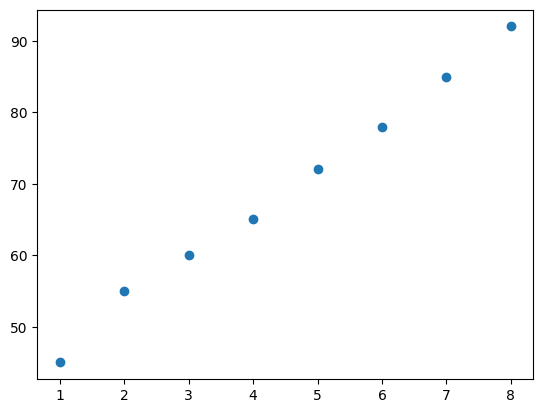

In [ ]:
#Excercise 1
study_hours = [1, 2, 3, 4, 5, 6, 7, 8]
test_scores = [45, 55, 60, 65, 72, 78, 85, 92]
plt.scatter(study_hours, test_scores)

#Excercise2
np.polyfit(study_hours, test_scores, 1)


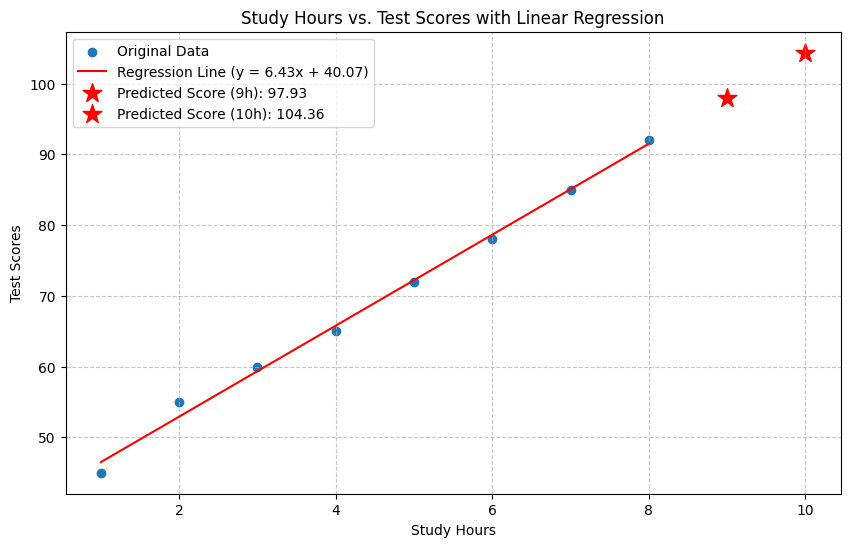

In [ ]:
#Excercise 2
slope, intercept = np.polyfit(study_hours, test_scores, 1)

# Create the linear regression line
regression_line = [slope * hours + intercept for hours in study_hours]

# Plot the scatter plot and the regression line
plt.figure(figsize=(10, 6))
plt.scatter(study_hours, test_scores, label='Original Data')
plt.plot(study_hours, regression_line, color='red', label=f'Regression Line (y = {slope:.2f}x + {intercept:.2f})')
plt.title('Study Hours vs. Test Scores with Linear Regression')
plt.xlabel('Study Hours')
plt.ylabel('Test Scores')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Calculate predictions for 9 and 10 hours
predicted_score_9_hours = slope * 9 + intercept
predicted_score_10_hours = slope * 10 + intercept

# Plot the predicted points as red stars
plt.scatter(9, predicted_score_9_hours, color='red', marker='*', s=200, label=f'Predicted Score (9h): {predicted_score_9_hours:.2f}')
plt.scatter(10, predicted_score_10_hours, color='red', marker='*', s=200, label=f'Predicted Score (10h): {predicted_score_10_hours:.2f}')

plt.legend()
plt.show()

In [ ]:
pip install scikit-learn

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

study_hours = np.array([1, 2, 3, 4, 5, 6, 7, 8])
sleep_hours = np.array([3, 7, 4, 2, 5, 6, 2, 9])
test_scores = [45, 55, 60, 65, 72, 78, 85, 92]

# combine the two features into one table: each row = [study, sleep]
X = np.column_stack((study_hours, sleep_hours))

model = LinearRegression()
model.fit(X, test_scores)

print("Slope for study_hours:", model.coef_[0])
print("Slope for sleep_hours:", model.coef_[1])
print("Intercept:", model.intercept_)
print("R-squared:", model.score(X, test_scores))

Slope for study_hours: 6.3468033775633295
Slope for sleep_hours: 0.2641737032569364
Intercept: 39.18455971049457
R-squared: 0.9968286926882173


In [ ]:
!pip install yahoofinance

In [ ]:
import yfinance as yf

In [ ]:
aapl = yf.download('AAPL')

/tmp/ipykernel_586/3726700954.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl = yf.download('AAPL')
[*********************100%***********************]  1 of 1 completed


In [ ]:
import yfinance as yf
import numpy as np
from sklearn.linear_model import LinearRegression

data = yf.download("AAPL", start="2023-01-01", end="2026-01-01")
close = data["Close"]
volume = data["Volume"]

returns = close.pct_change().dropna()

# Exercise 3: yesterday's return -> today's return
X3 = returns.values[:-1].reshape(-1, 1)
y3 = returns.values[1:]

model3 = LinearRegression()
model3.fit(X3, y3)
print("Exercise 3 R-squared:", model3.score(X3, y3))

# Exercise 4: previous return, volume change, 5-day MA -> today's return
volume_change = volume.pct_change().dropna()
moving_avg_5 = close.rolling(5).mean().dropna()

min_len = min(len(returns) - 1, len(volume_change) - 1, len(moving_avg_5) - 1)

prev_return = returns.values[-min_len:]
vol_change = volume_change.values[-min_len:]
ma5 = moving_avg_5.values[-(min_len + 1):-1]
y4 = returns.values[-min_len:]

X4 = np.column_stack((prev_return, vol_change, ma5))

model4 = LinearRegression()
model4.fit(X4, y4)
print("Exercise 4 R-squared:", model4.score(X4, y4))
print("Coefficients:", model4.coef_)

/tmp/ipykernel_586/1749264545.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2023-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed

Exercise 3 R-squared: 0.0024733341207587856
Exercise 4 R-squared: 1.0
Coefficients: [[ 1.00000000e+00  5.55565538e-19 -1.07344921e-20]]


In [ ]:
from sklearn.metrics import accuracy_score


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

y_binary = (y3 > 0).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X3, y_binary, test_size=0.2, random_state=42)
logistic_model = LogisticRegression().fit(X_train, y_train)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, logistic_model.predict(X_test)):.4f}")

Logistic Regression Accuracy: 0.5600


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
daily_returns = data['Close'].squeeze().pct_change()

current_day_return = daily_returns

current_day_volume_change = data['Volume'].squeeze().pct_change()

current_day_ma5 = data['Close'].squeeze().rolling(5).mean()

tomorrow_direction = (daily_returns.shift(-1) > 0).astype(int)

combined_data = pd.DataFrame({
    'current_day_return': current_day_return,
    'volume_change': current_day_volume_change,
    'ma5': current_day_ma5,
    'target': tomorrow_direction
}).dropna()

X = combined_data[['current_day_return', 'volume_change', 'ma5']].values
y = combined_data['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False, random_state=42)

logistic_model = LogisticRegression(random_state=42, solver='liblinear')
logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")

if accuracy > 0.5:
    print("KEY QUESTION: The model's accuracy is better than 50%.")
elif accuracy < 0.5:
    print("KEY QUESTION: The model's accuracy is not better than 50%.")
else:
    print("KEY QUESTION: The model's accuracy is exactly 50% (equivalent to a coin flip).")

Logistic Regression Accuracy: 0.5133
KEY QUESTION: The model's accuracy is better than 50%.
